In [3]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Install dependencies
!pip install torch torchvision scikit-learn matplotlib seaborn -q

In [5]:
# Imports
import numpy as np
import json
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Load data
BASE = "/content/drive/MyDrive/signverse-ml"

X_train = np.load(f"{BASE}/X_train_aug.npy")
y_train = np.load(f"{BASE}/y_train_aug.npy")
X_val   = np.load(f"{BASE}/X_val.npy")
y_val   = np.load(f"{BASE}/y_val.npy")
X_test  = np.load(f"{BASE}/X_test.npy")
y_test  = np.load(f"{BASE}/y_test.npy")

with open(f"{BASE}/label_map.json") as f:
    label_map = json.load(f)

NUM_CLASSES = len(label_map)
print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")
print(f"Classes: {NUM_CLASSES}")

Train : (140400, 63)
Val   : (10029, 63)
Test  : (10029, 63)
Classes: 29


In [6]:
# Create Pytorch datasets
# Convert to tensors
X_train_t = torch.FloatTensor(X_train)
y_train_t = torch.LongTensor(y_train)
X_val_t   = torch.FloatTensor(X_val)
y_val_t   = torch.LongTensor(y_val)
X_test_t  = torch.FloatTensor(X_test)
y_test_t  = torch.LongTensor(y_test)

# Create datasets and loaders
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds   = TensorDataset(X_val_t,   y_val_t)
test_ds  = TensorDataset(X_test_t,  y_test_t)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=256)
test_loader  = DataLoader(test_ds,  batch_size=256)

print("Dataloaders ready.")

Dataloaders ready.


In [7]:
#Define the model
class AlphabetClassifier(nn.Module):
    def __init__(self, input_size=63, num_classes=29):
        super().__init__()
        self.net = nn.Sequential(
            # Layer 1
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 2
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Layer 3
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Layer 4
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Output
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = AlphabetClassifier(input_size=63, num_classes=NUM_CLASSES).to(device)
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

Using device: cuda
Parameters: 318,237


In [8]:
#Training setup
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=5, factor=0.5
)

EPOCHS = 50
best_val_acc = 0
best_model_state = None
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

In [9]:
#Training loop
for epoch in range(EPOCHS):
    # ── Train ──────────────────────────────────────────
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item()
        preds          = outputs.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total   += len(y_batch)

    train_acc  = train_correct / train_total
    train_loss = train_loss / len(train_loader)

    # ── Validate ───────────────────────────────────────
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs    = model(X_batch)
            loss       = criterion(outputs, y_batch)
            val_loss  += loss.item()
            preds      = outputs.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total  += len(y_batch)

    val_acc  = val_correct / val_total
    val_loss = val_loss / len(val_loader)

    # ── Scheduler + save best ─────────────────────────
    scheduler.step(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        print(f"  ✓ New best model saved (val_acc={val_acc:.4f})")

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

print(f"\nBest Val Accuracy: {best_val_acc:.4f}")

  ✓ New best model saved (val_acc=0.9581)
Epoch   1/50 | Train Loss: 0.5508 | Train Acc: 0.8548 | Val Loss: 0.1547 | Val Acc: 0.9581
Epoch   2/50 | Train Loss: 0.1995 | Train Acc: 0.9403 | Val Loss: 0.1580 | Val Acc: 0.9538
  ✓ New best model saved (val_acc=0.9665)
Epoch   3/50 | Train Loss: 0.1671 | Train Acc: 0.9496 | Val Loss: 0.1202 | Val Acc: 0.9665
  ✓ New best model saved (val_acc=0.9767)
Epoch   4/50 | Train Loss: 0.1468 | Train Acc: 0.9555 | Val Loss: 0.0821 | Val Acc: 0.9767
Epoch   5/50 | Train Loss: 0.1353 | Train Acc: 0.9585 | Val Loss: 0.1242 | Val Acc: 0.9626
Epoch   6/50 | Train Loss: 0.1276 | Train Acc: 0.9609 | Val Loss: 0.1066 | Val Acc: 0.9666
Epoch   7/50 | Train Loss: 0.1198 | Train Acc: 0.9629 | Val Loss: 0.0949 | Val Acc: 0.9719
  ✓ New best model saved (val_acc=0.9772)
Epoch   8/50 | Train Loss: 0.1149 | Train Acc: 0.9648 | Val Loss: 0.0772 | Val Acc: 0.9772
  ✓ New best model saved (val_acc=0.9778)
Epoch   9/50 | Train Loss: 0.1111 | Train Acc: 0.9657 | Val Lo

In [10]:
#Evaluate on test set
# Load best model
model.load_state_dict(best_model_state)
model.eval()

test_correct, test_total = 0, 0
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        outputs = model(X_batch)
        preds   = outputs.argmax(dim=1)
        test_correct += (preds == y_batch).sum().item()
        test_total   += len(y_batch)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

test_acc = test_correct / test_total
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Test Accuracy: 0.9924 (99.24%)


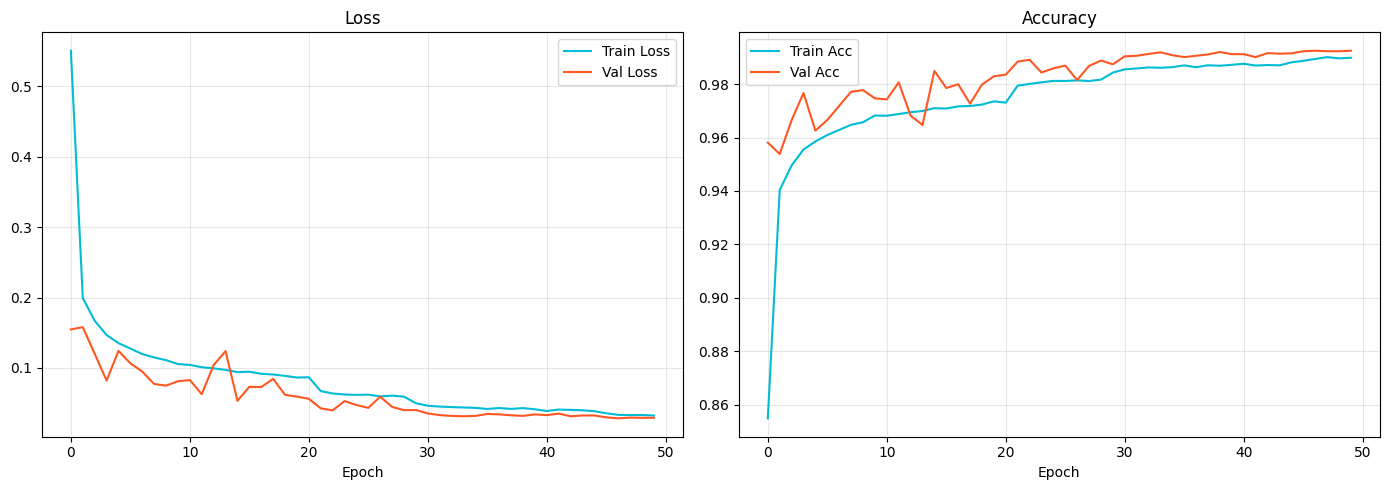

Saved training curves.


In [11]:
#Plot training curves
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss", color="#00BCD4")
ax1.plot(history["val_loss"],   label="Val Loss",   color="#FF5722")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history["train_acc"], label="Train Acc", color="#00BCD4")
ax2.plot(history["val_acc"],   label="Val Acc",   color="#FF5722")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{BASE}/alphabet_training_curves.png", dpi=150)
plt.show()
print("Saved training curves.")

In [12]:
#Save the model
import os

# Save PyTorch model
torch.save({
    "model_state_dict": best_model_state,
    "model_config": {"input_size": 63, "num_classes": NUM_CLASSES},
    "val_accuracy": best_val_acc,
    "test_accuracy": test_acc,
    "label_map": label_map,
}, f"{BASE}/alphabet_model.pth")

print(f"Model saved to Google Drive.")
print(f"Val  accuracy : {best_val_acc*100:.2f}%")
print(f"Test accuracy : {test_acc*100:.2f}%")

Model saved to Google Drive.
Val  accuracy : 99.25%
Test accuracy : 99.24%


In [13]:
#Install TensorFlow
!pip install tensorflow -q

In [14]:
#Rebuild model and load best weights
import torch
import torch.nn as nn
import numpy as np

class AlphabetClassifier(nn.Module):
    def __init__(self, input_size=63, num_classes=29):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.net(x)

# Load saved model
BASE = "/content/drive/MyDrive/signverse-ml"
checkpoint = torch.load(f"{BASE}/alphabet_model.pth", map_location="cpu")

model = AlphabetClassifier(
    input_size=checkpoint["model_config"]["input_size"],
    num_classes=checkpoint["model_config"]["num_classes"]
)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
print("Model loaded successfully.")

Model loaded successfully.


In [16]:
#Install onnx
!pip install -q onnx onnxscript

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 70.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 51.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 18.5 MB/s eta 0:00:00


In [17]:
#Export to ONNX
import torch.onnx

dummy_input = torch.randn(1, 63)
onnx_path = f"{BASE}/alphabet_model.onnx"

torch.onnx.export(
    model,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=11,
    do_constant_folding=True,
    input_names=["landmarks"],
    output_names=["logits"],
    dynamic_axes={
        "landmarks": {0: "batch_size"},
        "logits":    {0: "batch_size"},
    }
)
print(f"ONNX model saved to {onnx_path}")

/tmp/ipykernel_435/3591497193.py:7: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W0606 04:01:20.253000 435 torch/onnx/_internal/exporter/_compat.py:133] Setting ONNX exporter to use operator set version 18 because the requested opset_version 11 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


[torch.onnx] Obtain model graph for `AlphabetClassifier([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `AlphabetClassifier([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
ONNX model saved to /content/drive/MyDrive/signverse-ml/alphabet_model.onnx


In [21]:
#Install ai_edge_torch
!pip install litert-torch -q

In [22]:
import litert_torch
import torch

sample_input = torch.randn(1, 63)

edge_model = litert_torch.convert(model.eval(), (sample_input,))

tflite_path = f"{BASE}/alphabet_model.tflite"
edge_model.export(tflite_path)

import os
size_kb = os.path.getsize(tflite_path) / 1024
print(f"TFLite model saved: {size_kb:.1f} KB")

(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions

/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


(00:00) [ DONE] LiteRT-Torch Convert > Torch Export: serving_default > ExportedProgram Run Decompositions (+00:00)

...

(00:02) [ DONE] LiteRT-Torch Convert > Run LiteRT Converter Passes (+00:00)

(00:02) [ DONE] LiteRT-Torch Convert (+00:02)

(00:00) [START] Write Model to /content/drive/MyDrive/signverse-ml/alphabet_model.tflite

(00:00) [ DONE] Write Model to /content/drive/MyDrive/signverse-ml/alphabet_model.tflite (+00:00)

TFLite model saved: 1238.9 KB


In [ ]:
#Verify TFLite model works correctly
import numpy as np
import tensorflow as tf

# Load TFLite model
interpreter = tf.lite.Interpreter(model_path=tflite_path)
interpreter.allocate_tensors()

input_details  = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Input shape  : {input_details[0]['shape']}")
print(f"Input dtype  : {input_details[0]['dtype']}")
print(f"Output shape : {output_details[0]['shape']}")

# Test with a real sample from the test set
X_test = np.load(f"{BASE}/X_test.npy")
y_test = np.load(f"{BASE}/y_test.npy")

# Run 100 predictions and check accuracy
correct = 0
for i in range(100):
    sample = X_test[i:i+1].astype(np.float32)
    interpreter.set_tensor(input_details[0]['index'], sample)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]['index'])
    pred = np.argmax(output)
    if pred == y_test[i]:
        correct += 1

print(f"TFLite accuracy on 100 samples: {correct}%")
print("TFLite model verified and ready for mobile deployment.")

Input shape  : [ 1 63]
Input dtype  : <class 'numpy.float32'>
Output shape : [ 1 29]
TFLite accuracy on 100 samples: 99%
TFLite model verified and ready for mobile deployment.


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
